# Examples (pred, agent / participle)

## Table of content (ToC)<a class="anchor" id="TOC"></a>
* <a href="#bullet1">1 - Introduction</a>
* <a href="#bullet2">2 - Load TF with N1904addons</a>
* <a href="#bullet3">3 - Object-subject-verb relation</a>
    * <a href="#bullet3x1">3.1 - Get egde feature 'frame'</a>
    * <a href="#bullet3x2">3.2 - Make first selection (pred + subj)</a>
    * <a href="#bullet3x3">3.3 - Limit the selection further</a>
    * <a href="#bullet3x4">3.4 - Create some stats</a>
    * <a href="#bullet3x5">3.5 - Generate a meat map</a>
    * <a href="#bullet3x6">3.6 - Now bring in the morphological ambiguity</a>    
    * <a href="#bullet3x7">3.7 - First examine the extent of alternative interpretations (for any lemma)</a>
    * <a href="#bullet3x8">3.8 - Now examine the extent of alternative interpretations (same lemma)</a>
    * <a href="#bullet3x9">3.9 - Now see what is actualy changing</a>    
    * <a href="#bullet3x10">3.10 - Now plot the number of variances</a>
    * <a href="#bullet3x11">3.11 - Better is to plot using grammatical features</a>
    * <a href="#bullet3x12">3.12 - Show the TF syntax trees</a>    
* <a href="#bullet4">4 - Attribution and footnotes</a>
* <a href="#bullet5">5 - Required libraries</a>
* <a href="#bullet6">6 - Notebook version</a>


#  1 - Introduction <a class="anchor" id="bullet1"></a>
##### [Back to ToC](#TOC)

This Jupyter Notebook demonstrates a usecase of the N1904addon feature set.

# 2 -  Load TF with N1904addons <a class="anchor" id="bullet2"></a>
##### [Back to ToC](#TOC)

In [1]:
# Load the autoreload extension to automatically reload modules before executing code
%load_ext autoreload
%autoreload 2

In [2]:
# Loading the Text-Fabric code
from tf.fabric import Fabric
from tf.app import use

In [3]:
# Load the N1904-TF app and data with the additional features
A = use ("CenterBLC/N1904", mod="tonyjurg/N1904addons/tf", silence="terse", hoist=globals())

**Locating corpus resources ...**

Name,# of nodes,# slots / node,% coverage
book,27,5102.93,100
chapter,260,529.92,100
verse,7944,17.34,100
sentence,8011,17.20,100
group,8945,7.01,46
clause,42506,8.36,258
wg,106868,6.88,533
phrase,69007,1.90,95
subphrase,116178,1.60,135
word,137779,1.00,100


Display is setup for viewtype [syntax-view](https://github.com/saulocantanhede/tfgreek2/blob/main/docs/syntax-view.md#start)

See [here](https://github.com/saulocantanhede/tfgreek2/blob/main/docs/viewtypes.md#start) for more information on viewtypes

In [4]:
# The following will push the Text-Fabric stylesheet to this notebook (to facilitate proper display with notebook viewer)
A.dh(A.getCss())

# 3 - Object-subject-verb relation<a class="anchor" id="bullet3"></a>
##### [Back to ToC](#TOC)

## 3.1 - Get egde feature 'frame' <a class="anchor" id="bullet3x1"></a>

In this codeblock I utilize the edge feature [frame]() which contains Semantic Role Labeling. We will query to extract verbs with their associated subjects (A0). For each match the code pulls grammatical case,  tense, mood, and voice features. Then it counts them using a compound key and stores the totals in a Counter. The last step is to transform the counter into a sorted list of tuples and prints the top entries in a formatted table showing object-case, tense, mood, voice, subject-case, and count.

In [5]:
E.frame.freqList()

(('A0', 25654), ('A1', 15570), ('A2', 2577), ('AA2', 92))

In [6]:
# edge faature with Semantic Role Labeling
frameData = dict(E.frame.items())

This shows that data is actually using a two‐level mapping:

- outer key u is the source node

- inner mapping is { v: val, … } giving each target v and its feature value val

So the following can be done:

In [7]:
from collections import Counter
# Build a counter of nodeTypes just to make sure they only are only of type word
nodeTypes = Counter()
for key, role_map in frameData.items():
    nodeTypes[F.otype.v(key)]+=1
nodeTypes

Counter({'word': 25491})

## 3.2 - Make first selection (pred + subj) <a class="anchor" id="bullet3x2"></a>

In [8]:
# Semantic Role Labeling edge feature
# Feature is called 'frame' as it follows Frame semantics
# A0 = Agent or subject of the action (prototypical agent)
# A1 = Direct object or the entity directly affected by the action (prototypical patient)
# A2 = Indirect object or secondary entity affected by the action (prototypical recipient)

# keep only those u where its targets.values() has both 'A0' and 'A1'
filtered = {
    u: targets
    for u, targets in frameData.items()
    if 'A0' in targets.values() and targets.values()
}

I want exactly one edge value: only A0 (subject/agent)

In [9]:
exact_pairs = {
    u: targets
    for u, targets in frameData.items()
    if len(targets) == 1 and set(targets.values()) == {'A0'}
}
len(exact_pairs)

9484

That will give only the outer keys whose inner dict has exactly two entries, one labeled A0 and one labeled A1. But we should be cautions to assume they are always in the same order. Since we can not rely on Python’s normal unpacking to know which key is which, we need to explicitly pick out the “A0” index and the “A1” index from your inner dict. The cleanest way is to invert that mapping and then pull out the two roles by name. 

However, from the datadump before we also know that there can be cases where there are for example multiple A1's, so we can not treat it as a single value. We need to collect all the A1 indices (and A0, and A2 as well) into a list first. But at this point (since using exact_pairs) we still can do this the simple way...

In [10]:
# Build a Counter of tuples
freq = Counter()

for pred, (agent,) in exact_pairs.items():

    s_pred    = F.sp.v(pred)      # predicate
    s_agent   = F.sp.v(agent)     # A0 (prototypical agent)

    freq[(s_pred, s_agent)] += 1
freq.most_common(20)

[(('verb', 'subs'), 5800),
 (('verb', 'verb'), 1474),
 (('verb', 'pron'), 1034),
 (('verb', 'adjv'), 880),
 (('verb', 'art'), 182),
 (('verb', 'num'), 94),
 (('verb', 'advb'), 10),
 (('verb', 'intj'), 6),
 (('verb', 'prep'), 2),
 (('verb', 'conj'), 2)]

## 3.3 - Limit the selection further  <a class="anchor" id="bullet3x3"></a>

Now we can take a subsection (verb, 'any word with case property').

In [11]:
from collections import Counter

dist = Counter()
for pred, (agent,) in exact_pairs.items():

    s_pred    = F.sp.v(pred)           # predicate
    c_agent   = F.case.v(agent) or ''    # A0 (prototypical agent)

    if s_pred=='verb' and c_agent!='':
        m_pred    = F.mood.v(pred)          # predicate
        t_pred    = F.tense.v(pred)         # predicate
        v_pred    = F.voice.v(pred)         # predicate
        c_agent   = F.case.v(agent)     # A0 (prototypical agent)
        dist[(m_pred, t_pred, v_pred, c_agent)] += 1

dist.most_common(20)

[(('indicative', 'aorist', 'active', 'nominative'), 1470),
 (('participle', 'present', 'active', 'nominative'), 726),
 (('indicative', 'present', 'active', 'nominative'), 677),
 (('participle', 'aorist', 'active', 'nominative'), 541),
 (('indicative', 'imperfect', 'active', 'nominative'), 285),
 (('participle', 'present', 'active', 'accusative'), 251),
 (('subjunctive', 'aorist', 'active', 'nominative'), 230),
 (('indicative', 'present', 'middlepassive', 'nominative'), 222),
 (('indicative', 'aorist', 'middle', 'nominative'), 213),
 (('participle', 'present', 'active', 'genitive'), 206),
 (('indicative', 'perfect', 'active', 'nominative'), 173),
 (('participle', 'present', 'middlepassive', 'nominative'), 142),
 (('indicative', 'future', 'middle', 'nominative'), 139),
 (('infinitive', 'aorist', 'active', 'accusative'), 133),
 (('imperative', 'present', 'active', 'nominative'), 131),
 (('infinitive', 'aorist', 'active', 'nominative'), 130),
 (('indicative', 'future', 'active', 'nominativ

## 3.4 - Create some stats <a class="anchor" id="bullet3x4"></a>

This codeblock builds a pandas DataFrame from the nested frequency counter (created in te previous codeblock) and then computes and prints simple 2D distributions of cases by tense, mood, and voice. it also creates some pivot tables showing how each case type varies simultaneously across tense, mood, and voice.

In [12]:
import pandas as pd

# Build a common DataFrame
rows = [
    {
      "m_pred":     m_pred,
      "t_pred":     t_pred,
      "v_pred":     v_pred,
      "c_agent":    c_agent,
      "count":      count
    }
    for (m_pred, t_pred, v_pred, c_agent), count in dist.items()
]
df = pd.DataFrame(rows)

In [13]:
# Distribution of agent's case by tense of the predicate
agent_by_tense = (
    df
    .groupby(["t_pred","c_agent"])["count"]
    .sum()
    .unstack(fill_value=0)
)
print("Agent-case distribution by predicate tense:\n", agent_by_tense, "\n")

Agent-case distribution by predicate tense:
 c_agent     accusative  dative  genitive  nominative  vocative
t_pred                                                        
aorist             415     206       247        2839       168
future              17      18        14         281        16
imperfect           19      10        16         377         5
perfect             73      21        39         257        43
pluperfect           0       0         2          36         2
present            626     313       388        2196       266 



In [14]:
# Distribution of agent's case by mood of the predicate
agent_by_mood = (
    df
    .groupby(["m_pred","c_agent"])["count"]
    .sum()
    .unstack(fill_value=0)
)
print("Agent-case distribution by predicate mood:\n", agent_by_mood, "\n")

Agent-case distribution by predicate mood:
 c_agent      accusative  dative  genitive  nominative  vocative
m_pred                                                         
imperative           69      94        50         304       184
indicative          211     152       146        3506       171
infinitive          311      56        29         266        47
optative              1       1         2           7         1
participle          521     250       448        1544        57
subjunctive          37      15        31         359        40 



In [15]:
# Distribution of agent's case by voice of the predicate
agent_by_voice = (
    df
    .groupby(["v_pred","c_agent"])["count"]
    .sum()
    .unstack(fill_value=0)
)
print("Agent-case distribution by predicate voice:\n", agent_by_voice, "\n")

Agent-case distribution by predicate voice:
 c_agent        accusative  dative  genitive  nominative  vocative
v_pred                                                           
active                878     437       534        4857       400
middle                 94      43        72         526        45
middlepassive         166      81        92         534        50
passive                12       7         8          69         5 



In [16]:
# Multi-dimensional pivot: (c_agent or c_patient) vs. (t_pred, m_pred, v_pred)
pivot_agent = df.pivot_table(
    index="c_agent",
    columns=["t_pred","m_pred","v_pred"],
    values="count",
    aggfunc="sum",
    fill_value=0
)

print("Case agent × (Tense,Mood,Voice) predicate:\n", pivot_agent.head(), "\n")


Case agent × (Tense,Mood,Voice) predicate:
 t_pred         aorist                                                      \
m_pred     imperative                indicative                infinitive   
v_pred         active middle passive     active middle passive     active   
c_agent                                                                     
accusative         16     23       0         87      6       0        133   
dative             19     11       0         65      6       0         24   
genitive           14     13       0         49      1       0         13   
nominative         92     35       1       1470    213      30        130   
vocative           54     29       0         35      1       0         14   

t_pred                              ...  present                           \
m_pred                    optative  ... optative               participle   
v_pred     middle passive   active  ...   active middlepassive     active   
c_agent                        

## 3.5 - Generate a meat map <a class="anchor" id="bullet3x5"></a>

This following codeblock takes the raw counts of how often different grammatical cases (object vs. subject) co-occur with various verb features (tense, mood, voice) in our N1904-TF dataset. It organizes this data into pivot tables, and then renders a 3×1 grid of heatmaps. Each heatmap shows which verb property (mood, tense or voice) most frequently appear with particular subject-cases. This visualizes the patterns found in the N1904-TF morphosyntactic data at a glance.

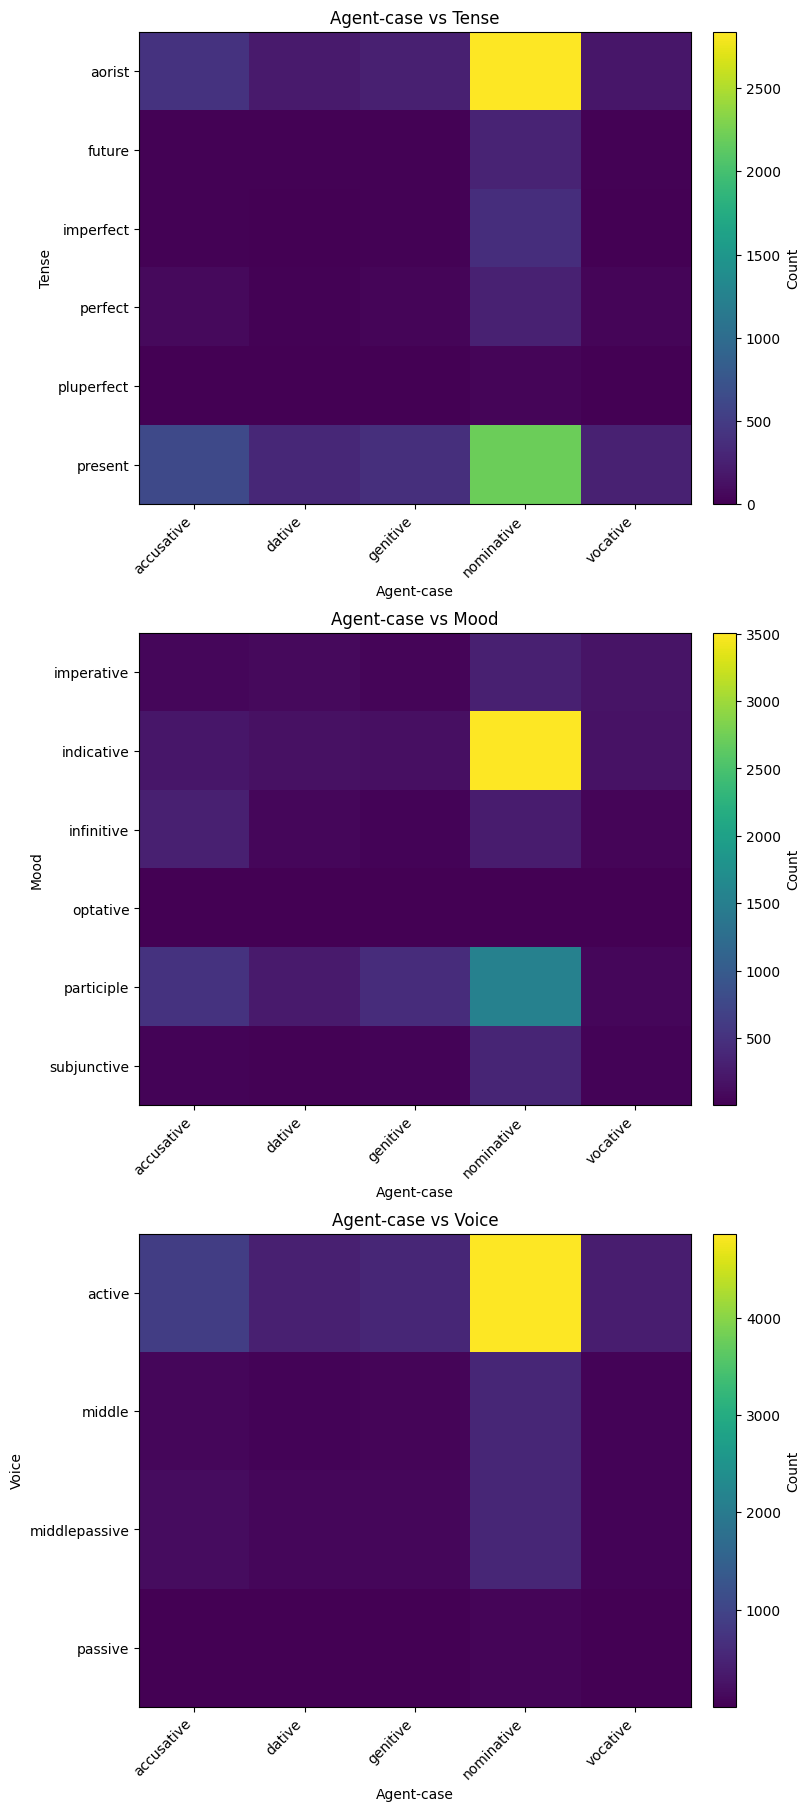

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Prepare the pivot tables
pivots = {
    "Agent-case vs Tense":   df.groupby(["t_pred","c_agent"])["count"].sum().unstack(fill_value=0),
    "Agent-case vs Mood":    df.groupby(["m_pred","c_agent"])["count"].sum().unstack(fill_value=0),
    "Agent-case vs Voice":   df.groupby(["v_pred","c_agent"])["count"].sum().unstack(fill_value=0),
}

# Mapping from DataFrame names to pretty axis labels
var_labels = {
    "t_pred":   "Tense",
    "m_pred":   "Mood",
    "v_pred":   "Voice",
    "c_agent":  "Agent-case",
}

# Draw them all in a 3×1 grid 
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8,18), constrained_layout=True)

for ax, (title, pivot) in zip(axes.flat, pivots.items()):
    im = ax.imshow(pivot.values, aspect="auto")
    ax.set_title(title)
    
    # lookup nice axis‐labels based on the DataFrame’s index/column names
    y_name = pivot.index.name      # "t_pred", "m_pred", or "v_pred"
    x_name = pivot.columns.name    # "c_patient" or "c_agent"
    ax.set_ylabel(var_labels[y_name])
    ax.set_xlabel(var_labels[x_name])
    
    # set the tick‐labels
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=10)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=10)
    
    # add a colorbar
    cbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
    cbar.set_label("Count")

plt.show()


## 3.6 - Now bring in the morphological ambiguity <a class="anchor" id="bullet3x6"></a>

We will use the feature `m*_gram_dif` grammatical difference against N1904-TF (field) which quantify grammatical differences between the Morpheus analyses and the N1904-TF annotations, which in this context is regarded the reference. Each feature in this group annotates a wordnode with a 9-character string indicating whether Morpheus’s analysis  **differs** from the reference. Differences are indicated using a `letter` while matches are indicated usint a dot (`.`). 

Feature(s) | Description
---|---
[md{num}_gram_dif](md{num}_gram_dif) | grammatical difference against N1904-TF, with num in the range (1-24), inclusive.
[ms{num}_gram_dif](ms{num}_gram_dif.md) | grammatical difference against N1904-TF, with num in range (1-12), inclusive.
[mm_gram_dif](mm_gram_dif.md) | grammatical difference against N1904-TF 


Each value for a feature `m*_gram_dif` produces a fixed-length string of 9 characters. Characters are drawn from:

* A dot (`.`) when Morpheus and N1904-TF agree (including when both values are `None`).
* A letter (one of `l p c n g t m v d`) when Morpheus differs, indicating which category is mismatched.
* The character positions correspond to the canonical order of morphological features shown in the following table.

| Position | Field Key | Grammatical Property 
| :------: | :-------: | :------------------: 
|     0    |    `l`    |         Lemma        
|     1    |    `p`    |        Person        
|     2    |    `c`    |         Case         
|     3    |    `n`    |        Number        
|     4    |    `g`    |        Gender        
|     5    |    `t`    |         Tense        
|     6    |    `m`    |         Mood         
|     7    |    `v`    |         Voice        
|     8    |    `d`    |        Degree        


## 3.7 - First examine the extent of alternative interpretations (for any lemma) <a class="anchor" id="bullet3x7"></a>

First step is to identify **any** possible alternative interpretation (even when it relates to a different lemma).

Cache the `gram_dif` features (trick to allow working with hundreds of features ligtning fast):

In [18]:
MD_BLOCK_RANGE  = range(1, 25)
MS_BLOCK_RANGE  = range(1, 10)
md_gram_dif_feat   = {b: Fs(f"md{b}_gram_dif")  for b in MD_BLOCK_RANGE}
ms_gram_dif_feat   = {b: Fs(f"ms{b}_gram_dif")  for b in MS_BLOCK_RANGE}
ms_lemma_feat      = {b: Fs(f"ms{b}_lem_base_uc")  for b in MS_BLOCK_RANGE}

Now I start the again with the previous generated `exact_pairs`:

In [19]:
from collections import Counter, defaultdict
import numpy as np
import pandas as pd

def safe_char(s, pos, default='_'):
    #  If s is a (non-None) string of length > pos, return s[pos]; otherwise return default.
    if isinstance(s, str) and len(s) > pos:  return s[pos]
    return default

# Build up rows of features:
rows = []
for pred, (agent,) in exact_pairs.items():

    # only verbs with participle agent
    if F.sp.v(pred)=='verb' and F.mood.v(agent)=='participle':
        # base features of the verb
        t_pred = F.tense.v(pred)
        m_pred = F.mood.v(pred)
        v_pred = F.voice.v(pred)
        # base features of the participle
        t_agent = F.tense.v(agent)
        m_agent = F.mood.v(agent)
        v_agent = F.voice.v(agent)
        c_agent = F.case.v(agent)
        g_agent = F.gender.v(agent)
        n_agent = F.number.v(agent) 

        # the raw mm_gram_dif strings (this means ANY possible interpretation)
        diffs_pred   = F.mm_gram_dif.v(pred)    or ''
        diffs_agent  = F.mm_gram_dif.v(agent)   or ''

        rows.append({
            't_pred':    t_pred,
            'm_pred':    m_pred,
            'v_pred':    v_pred,
            
            't_agent':  t_agent,
            'm_agent':  m_agent,
            'v_agent':  v_agent,
            'c_agent':  c_agent,
            'g_agent':  g_agent,
            'n_agent':  n_agent, 

            # extract the proper character from the gram_dif field
            'dm_pred':   safe_char(diffs_pred, 6),
            'dv_pred':   safe_char(diffs_pred, 7),
            'dt_pred':   safe_char(diffs_pred, 5),
            
            'dt_agent':  safe_char(diffs_agent, 5),       
            'dm_agent':  safe_char(diffs_agent,6),
            'dv_agent':  safe_char(diffs_agent, 7),       
            'dc_agent':  safe_char(diffs_agent,2),
            'dg_agent':  safe_char(diffs_agent,4),
            'dn_agent':  safe_char(diffs_agent,3),
        })

df_feats = pd.DataFrame(rows)

comparison_specs = [
    ('Tense',         't_pred',   'dt_pred'),
    ('Mood',          'm_pred',   'dm_pred'),
    ('Voice',         'v_pred',   'dv_pred'),
    ('Agent-case',    'c_agent',  'dc_agent'),
    ('Agent-gender',  'g_agent',  'dg_agent'),
    ('Agent-number',  'n_agent',  'dn_agent'),
]

summary = []
N = len(df_feats)
default = '_'   # my safe_char default


for feat_name, base_col, diff_col in comparison_specs:
    valid_mask = df_feats[diff_col] != default
    n_valid    = valid_mask.sum()
    n_missing  = N - n_valid

    n_true_diffs = ((df_feats[diff_col] != default) & (df_feats[diff_col] != '.')).sum()
    pct_true     = (100 * n_true_diffs / n_valid) if n_valid else float('nan')

    summary.append({
        'Feature':          feat_name,
        'Total samples':    N,
        'Diff Available':   n_valid,
        'Missing Diffs':    n_missing,
        'True Diffs':       n_true_diffs,
        'Pct of Available': f"{pct_true:.1f}%"
    })

summary_df = pd.DataFrame(summary)

# Just print it:
print(summary_df.to_string(index=False))

     Feature  Total samples  Diff Available  Missing Diffs  True Diffs Pct of Available
       Tense           1018            1014              4         307            30.3%
        Mood           1018            1014              4         360            35.5%
       Voice           1018            1014              4         374            36.9%
  Agent-case           1018            1015              3         662            65.2%
Agent-gender           1018            1015              3         489            48.2%
Agent-number           1018            1015              3         276            27.2%


Note that the entries in the dict `rows` looks like:
``` 
[{'t_pred': 'future',
  'm_pred': 'indicative',
  'v_pred': 'middle',
  'c_agent': 'nominative',   <- particple
  'dt_pred': '.',            <- the dot indicates there is Morpheus data, but that shows no alternative for tense
  'dm_pred': '.',
  'dv_pred': 'v',            <- in this example there is an alternative interpretation for voice
  'dc_agent': '.'},
```

## 3.8 - Now examine the extent of alternative interpretations (same lemma) <a class="anchor" id="bullet3x8"></a>

Now we modify the previous code to go one step deeper. Only look for alternatives when they are for the same lemma as the one used in N1904-TF.

In [20]:
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import unicodedata

def norm(s):
    return unicodedata.normalize('NFC', s) if isinstance(s, str) else s

def safe_char(s, pos, default='_'):
    #  If s is a (non-None) string of length > pos, return s[pos]; otherwise return default.
    if isinstance(s, str) and len(s) > pos:  return s[pos]
    return default

# Build up rows of features:
feature_rows = []
for pred, (agent,) in exact_pairs.items():  

    # only verbs with nominal (sp=subs) agent & patient
    if F.sp.v(pred)=='verb' and F.mood.v(agent)=='participle':
        # base features
        l_pred = norm(F.lemma.v(pred))
        t_pred = F.tense.v(pred)
        m_pred = F.mood.v(pred)
        v_pred = F.voice.v(pred)
        l_agent = norm(F.lemma.v(agent))
        c_agent = F.case.v(agent)
        

        ms_pred, ms_agent = int(0), int(0)
        dt_pred, dm_pred, dv_pred = '-', '-', '-'
        dt_agent = dm_agent = dv_agent = dg_agent = dn_agent = dc_agent = '-'
        pred_gram_diff, agent_gram_diff = None, None
        
        # the raw mm_gram_dif strings (this means ANY possible interpretation)
        for idx in MS_BLOCK_RANGE:        
            
            # try pred          
            if ms_pred == 0:
                lm_pred=norm(ms_lemma_feat[idx].v(pred))
                if lm_pred and lm_pred==l_pred:  # exist and same lemma
                    g=ms_gram_dif_feat[idx].v(pred) 
                    dt_pred, dm_pred, dv_pred = g[5], g[6], g[7]
                    ms_pred= idx   # this is the key to the ms{idx}_* features
                    
            # try agent
            if ms_agent == 0:  
                lm_agent=norm(ms_lemma_feat[idx].v(agent))
                if lm_agent and lm_agent==l_agent: # exist and same lemma
                    g=ms_gram_dif_feat[idx].v(agent) 
                    dt_agent, dv_agent, dm_agent = g[5], g[7], g[6]
                    dg_agent, dn_agent, dc_agent = g[4], g[3], g[2]  
                    ms_agent= idx   # this is the key to the ms{idx}_* features

                        
            # only break out once we've got all three
            if ms_pred and ms_agent:
                break
                
        feature_rows.append({
            'pred': pred,  
            'l_pred': l_pred, 
            't_pred': t_pred, 
            'v_pred': v_pred,    
            'm_pred': m_pred,    
            'ms_pred': ms_pred,  
            'dt_pred': dt_pred, 
            'dv_pred': dv_pred, 
            'dm_pred': dm_pred, 
            
            'agent': agent,   
            'l_agent': l_agent, 
            't_agent':  t_agent,
            'v_agent':  v_agent, 
            'm_agent':  m_agent,  
            'g_agent':  g_agent,
            'n_agent':  n_agent, 
            'c_agent': c_agent,     
            'ms_agent': ms_agent, 
            'dt_agent':  dt_agent,
            'dv_agent':  dv_agent, 
            'dm_agent':  dm_agent,  
            'dg_agent':  dg_agent,
            'dn_agent':  dn_agent, 
            'dc_agent': dc_agent, 

        })

the entries in the dict feature_rows now looks like:
```
[{'pred': 533,
  'l_pred': 'ἐξέρχομαι',
  't_pred': 'future',
  'v_pred': 'middle',
  'm_pred': 'indicative',
  'ms_pred': 1,
  'dt_pred': '.',
  'dv_pred': '.',
  'dm_pred': '.',
  'agent': 534,
  'l_agent': 'ἡγέομαι',
  't_agent': 'present',
  'v_agent': 'active',
  'm_agent': 'participle',
  'g_agent': 'masculine',
  'n_agent': 'singular',
  'c_agent': 'nominative',
  'ms_agent': 1,
  'dt_agent': '.',
  'dv_agent': 'v',
  'dm_agent': '.',
  'dg_agent': '.',
  'dn_agent': '.',
  'dc_agent': '.'},
```

Now turn it into a dataframe

In [21]:
import pandas as pd

# Turn collected rows into a DataFrame
df = pd.DataFrame(feature_rows)

print("columns:", df.columns.tolist())
print(df.head())


columns: ['pred', 'l_pred', 't_pred', 'v_pred', 'm_pred', 'ms_pred', 'dt_pred', 'dv_pred', 'dm_pred', 'agent', 'l_agent', 't_agent', 'v_agent', 'm_agent', 'g_agent', 'n_agent', 'c_agent', 'ms_agent', 'dt_agent', 'dv_agent', 'dm_agent', 'dg_agent', 'dn_agent', 'dc_agent']
   pred     l_pred   t_pred         v_pred      m_pred  ms_pred dt_pred  \
0   533  ἐξέρχομαι   future         middle  indicative        1       .   
1   534    ἡγέομαι  present  middlepassive  participle        1       .   
2   829     θνῄσκω  perfect         active  indicative        0       -   
3   928       βοάω  present         active  participle        1       .   
4  1083    ἔρχομαι  present  middlepassive  participle        1       .   

  dv_pred dm_pred  agent  ...    g_agent   n_agent     c_agent ms_agent  \
0       .       .    534  ...  masculine  singular  nominative        1   
1       v       .    534  ...  masculine  singular  nominative        1   
2       -       -    832  ...  masculine  singular  

In [22]:
import pandas as pd

#  Predicate ambiguity 
df['alt_v_pred']  = (df['dv_pred'] == 'v').astype(int)
df['alt_m_pred']  = (df['dm_pred'] == 'm').astype(int)
df['alt_t_pred']  = (df['dt_pred'] == 't').astype(int)
# total number of ambiguous predicate slots (0–3)
df['alt_pred'] = df['alt_v_pred'] + df['alt_m_pred'] + df['alt_t_pred']
# predicate is ambiguous if any of its three slots are ambiguous
df['ambig_pred']  = df[['alt_v_pred','alt_m_pred', 'alt_t_pred']].any(axis=1)

#  Participial‐agent ambiguity (six slots)
df['alt_c_agent'] = (df['dc_agent'] == 'c').astype(int)
df['alt_t_agent'] = (df['dt_agent'] == 't').astype(int)
df['alt_m_agent'] = (df['dm_agent'] == 'm').astype(int)
df['alt_v_agent'] = (df['dv_agent'] == 'v').astype(int)
df['alt_g_agent'] = (df['dg_agent'] == 'g').astype(int)
df['alt_n_agent'] = (df['dn_agent'] == 'n').astype(int)

# agent is ambiguous if any of its six slots are ambiguous
df['ambig_agent'] = df[['alt_c_agent','alt_t_agent','alt_m_agent',
                       'alt_v_agent','alt_g_agent','alt_n_agent']].any(axis=1)

#  Total number of ambiguous slots per row (predicate + agent)
df['n_ambiguous_items'] = df['ambig_pred'].astype(int) + df['ambig_agent'].astype(int)

#  How many rows have 0, 1, or 2 ambiguous items?
print("Rows by ambiguous‐slot count:")
print(df['n_ambiguous_items'].value_counts().sort_index())

#  Distribution of predicate ambiguities
print("\nPredicate alt counts:")
print(df['alt_pred'].value_counts().sort_index())

# Distribution of each agent‐feature ambiguity
for col in ['alt_c_agent','alt_t_agent','alt_m_agent',
            'alt_v_agent','alt_g_agent','alt_n_agent']:
    print(f"\n{col} counts:")
    print(df[col].value_counts().sort_index())

Rows by ambiguous‐slot count:
n_ambiguous_items
0    303
1    367
2    348
Name: count, dtype: int64

Predicate alt counts:
alt_pred
0    602
1    240
2    135
3     41
Name: count, dtype: int64

alt_c_agent counts:
alt_c_agent
0    568
1    450
Name: count, dtype: int64

alt_t_agent counts:
alt_t_agent
0    906
1    112
Name: count, dtype: int64

alt_m_agent counts:
alt_m_agent
0    854
1    164
Name: count, dtype: int64

alt_v_agent counts:
alt_v_agent
0    826
1    192
Name: count, dtype: int64

alt_g_agent counts:
alt_g_agent
0    702
1    316
Name: count, dtype: int64

alt_n_agent counts:
alt_n_agent
0    906
1    112
Name: count, dtype: int64


In [23]:
print(df.columns.tolist())

['pred', 'l_pred', 't_pred', 'v_pred', 'm_pred', 'ms_pred', 'dt_pred', 'dv_pred', 'dm_pred', 'agent', 'l_agent', 't_agent', 'v_agent', 'm_agent', 'g_agent', 'n_agent', 'c_agent', 'ms_agent', 'dt_agent', 'dv_agent', 'dm_agent', 'dg_agent', 'dn_agent', 'dc_agent', 'alt_v_pred', 'alt_m_pred', 'alt_t_pred', 'alt_pred', 'ambig_pred', 'alt_c_agent', 'alt_t_agent', 'alt_m_agent', 'alt_v_agent', 'alt_g_agent', 'alt_n_agent', 'ambig_agent', 'n_ambiguous_items']


Now filtering out the cases where both elements are open for alternative interpretation.

In [24]:
# Filter: keep only rows where all three are ambiguous
df_both = df[df['n_ambiguous_items'] == 2]

print(f"Total rows with 2 ambiguous slots: {len(df_both)}")
print(df_both[['pred','agent',
                    'alt_pred','alt_c_agent',
                    'n_ambiguous_items']])

Total rows with 2 ambiguous slots: 348
        pred   agent  alt_pred  alt_c_agent  n_ambiguous_items
1        534     534         1            0                  2
4       1083    1083         1            0                  2
5       1171    1171         2            1                  2
7       1463    1463         2            0                  2
9       1624    1624         1            0                  2
...      ...     ...       ...          ...                ...
1005  136865  136865         1            1                  2
1006  136876  136876         2            1                  2
1007  136894  136894         1            0                  2
1013  137689  137689         2            1                  2
1014  137690  137689         1            1                  2

[348 rows x 5 columns]


## 3.9 - Now see what is actualy changing <a class="anchor" id="bullet3x9"></a>

In [25]:
# Iterate over the filtered rows and inspect the details of the nodes
for _, row in df_both.iterrows():

    pred                = row['pred']
    text_pred           = F.text.v(pred)
    morph_pred          = F.morph.v(pred)
    ms_pred             = row['ms_pred']
    ms_block_nums_pred  = Fs(f'ms{ms_pred}_block_nums').v(pred)
    ms_num_blocks_pred  = Fs(f'ms{ms_pred}_num_blocks').v(pred)
    ms_morph_pred       = Fs(f'ms{ms_pred}_morph').v(pred)

    agent               = row['agent']
    text_agent          = F.text.v(agent)
    morph_agent         = F.morph.v(agent)
    ms_agent            = row['ms_agent']
    ms_block_nums_agent = Fs(f'ms{ms_agent}_block_nums').v(agent)
    ms_num_blocks_agent = Fs(f'ms{ms_agent}_num_blocks').v(agent)
    ms_morph_agent      = Fs(f'ms{ms_agent}_morph').v(agent)
    
    print (f'PRED ({text_pred}): {morph_pred} --> {ms_morph_pred} ({ms_block_nums_pred})\nAGENT ({text_agent}): {morph_agent} --> {ms_morph_agent} ({ms_block_nums_agent})\n')


PRED (ἡγούμενος): V-PNP-NSM --> V-PMP-NSM-ATT (1)
AGENT (ἡγούμενος): V-PNP-NSM --> V-PMP-NSM-ATT (1)

PRED (ἐρχόμενος): V-PNP-NSM --> V-PEP-NSM (1)
AGENT (ἐρχόμενος): V-PNP-NSM --> V-PEP-NSM (1)

PRED (πρέπον): V-PAP-NSN --> V-PAP-NSN/V-PAP-VSN/V-PAP-VSM/V-PAP-ASN/V-IAI-1S/V-IAI-3P (1/2/3/4)
AGENT (πρέπον): V-PAP-NSN --> V-PAP-NSN/V-PAP-VSN/V-PAP-VSM/V-PAP-ASN/V-IAI-1S/V-IAI-3P (1/2/3/4)

PRED (καθημένοις): V-PNP-DPM --> V-RMP-DPM/V-RMP-DPN (1)
AGENT (καθημένοις): V-PNP-DPM --> V-RMP-DPM/V-RMP-DPN (1)

PRED (δαιμονιζομένους): V-PNP-APM --> V-PEP-APM (1)
AGENT (δαιμονιζομένους): V-PNP-APM --> V-PEP-APM (1)

PRED (σεληνιαζομένους): V-PNP-APM --> V-PEP-APM (1)
AGENT (σεληνιαζομένους): V-PNP-APM --> V-PEP-APM (1)

PRED (κρούοντι): V-PAP-DSM --> V-PAP-DSM/V-PAP-DSN/V-PAI-3P (1/2)
AGENT (κρούοντι): V-PAP-DSM --> V-PAP-DSM/V-PAP-DSN/V-PAI-3P (1/2)

PRED (εἰσερχόμενοι): V-PNP-NPM --> V-PEP-NPM/V-PEP-VPM (1)
AGENT (εἰσερχόμενοι): V-PNP-NPM --> V-PEP-NPM/V-PEP-VPM (1)

PRED (ἀποχωρεῖτε): V-PAM-2

```
AGENT (ἐρχόμενος): V-PNP-NSM --> V-PEP-NSM (1)

N1904-TF SP morph tag                      Morpheus -> SP morph tag eq.
V-PNP-NSM                                  V-PEP-NSM =
{                                          {
  "Part of Speech": "Verb",                  "Part of Speech": "Verb",
  "Tense": "Present",                        "Tense": "Present",
  "Voice": "Middle or Passive Deponent",     "Voice": "Middle or Passive",   <-- difference
  "Mood": "Participle",                      "Mood": "Participle",
  "Case": "Nominative",                      "Case": "Nominative",
  "Number": "Singular",                      "Number": "Singular",
  "Gender": "Masculine"                      "Gender": "Masculine"
}                                          }
```

## 3.10 - Now plot the number of variances <a class="anchor" id="bullet3x10"></a>

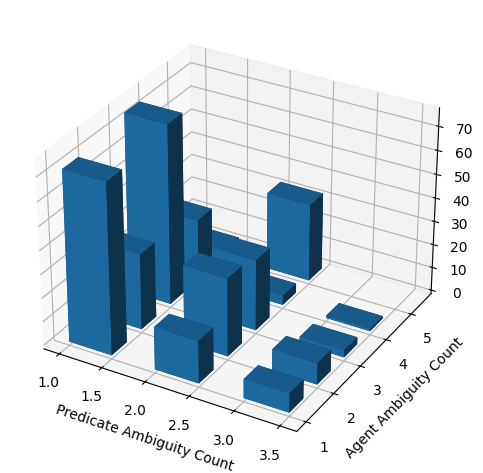

In [26]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Compute agent ambiguous feature count
df['agent_ambig_count'] = df_both[['alt_c_agent','alt_t_agent','alt_m_agent',
                              'alt_v_agent','alt_g_agent','alt_n_agent']].sum(axis=1)

# Aggregate counts by predicate ambiguity vs agent ambiguity
grouped = df.groupby(['alt_pred', 'agent_ambig_count']).size().reset_index(name='count')

# 3D bar chart
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

xs = grouped['alt_pred']
ys = grouped['agent_ambig_count']
zs = [0] * len(grouped)
dx = 0.5  # width of each bar along x
dy = 0.5  # width of each bar along y
dz = grouped['count']

ax.bar3d(xs, ys, zs, dx, dy, dz)

ax.set_xlabel('Predicate Ambiguity Count')
ax.set_ylabel('Agent Ambiguity Count')
ax.set_zlabel('Row Count')

plt.tight_layout()
plt.show()


**3-D bar chart explanation:**

X-axis (horizontal front-to-back) is the number of ambiguous predicate features (out of tense/mood/voice; thus in the range 0–3).

Y-axis (horizontal left-to-right) is the count of ambiguous agent features (out of case/tense/mood/voice/gender/number; so in range 0–6).

Z-axis (height) is the number of rows in your dataset with exactly that combination.

## 3.11 - Better is to plot using grammatical features <a class="anchor" id="bullet3x11"></a>

In [27]:
df = pd.DataFrame(feature_rows)           # or however df is built
df['alt_v_pred']  = (df['dv_pred'] == 'v').astype(int)
df['alt_m_pred']  = (df['dm_pred'] == 'm').astype(int)
df['alt_t_pred']  = (df['dt_pred'] == 't').astype(int)
df['alt_pred']    = df[['alt_v_pred','alt_m_pred','alt_t_pred']].sum(axis=1)
df['alt_c_agent'] = (df['dc_agent'] == 'c').astype(int)
df['alt_t_agent'] = (df['dt_agent'] == 't').astype(int)
df['alt_m_agent'] = (df['dm_agent'] == 'm').astype(int)
df['alt_v_agent'] = (df['dv_agent'] == 'v').astype(int)
df['alt_g_agent'] = (df['dg_agent'] == 'g').astype(int)
df['alt_n_agent'] = (df['dn_agent'] == 'n').astype(int)


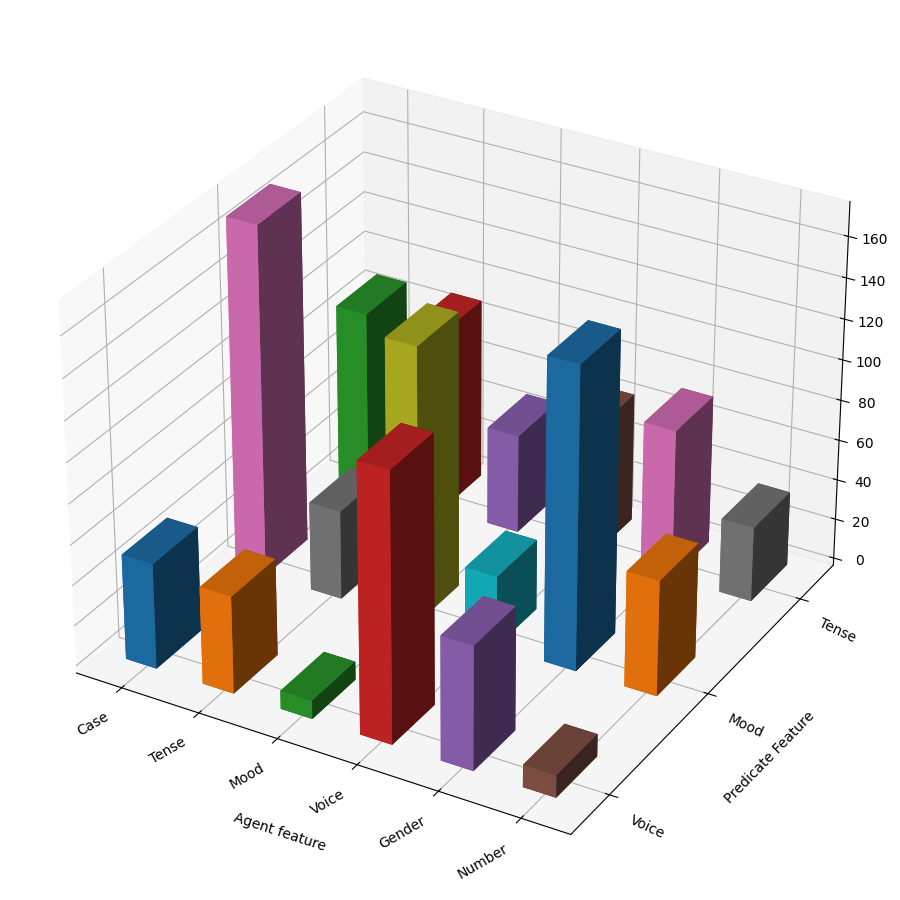

In [28]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

agent_features = [
    'alt_c_agent','alt_t_agent','alt_m_agent',
    'alt_v_agent','alt_g_agent','alt_n_agent'
]
agent_labels   = ['Case','Tense','Mood','Voice','Gender','Number']

pred_features  = ['alt_v_pred','alt_m_pred','alt_t_pred']
pred_labels    = ['Voice','Mood','Tense']

# Build count matrix
counts = np.zeros((len(pred_features), len(agent_features)), int)
for pi, pf in enumerate(pred_features):
    for ai, af in enumerate(agent_features):
        counts[pi, ai] = ((df[pf]==1) & (df[af]==1)).sum()

fig = plt.figure(figsize=(14,11))
ax  = fig.add_subplot(111, projection='3d')

dx, dy = 0.4, 0.4

for pi in range(len(pred_features)):
    for ai in range(len(agent_features)):
        ax.bar3d(ai, pi, 0, dx, dy, counts[pi, ai], shade=True)

# Ticks & labels
ax.set_xticks(np.arange(len(agent_features)) + dx/2)
ax.set_xticklabels(agent_labels, rotation=30, ha='right')
ax.set_yticks(np.arange(len(pred_features)) + dy/2)
ax.set_yticklabels(pred_labels, rotation=-25, ha='left')

# Move labels away from the tick‐values
ax.set_xlabel('Agent feature',      labelpad=20)
ax.set_ylabel('Predicate Feature',  labelpad=20)

# Bump the Z label way out so it clears the bars
ax.set_zlabel('Row Count',          labelpad=20)
# make sure it actually draws at that pad
ax.zaxis.label.set_rotation(90)

# Add extra margins so nothing gets clipped
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9)

plt.show()


## 3.12 - Show the TF syntax trees <a class="anchor" id="bullet3x12"></a>

In [45]:
duplets = [
    (row['pred'], row['agent'])
    for _, row in df_both.iterrows()
]

number_of_ms_sets=9
number_of_md_sets=25

morphFeatureList = (
   ['lemma','morph', 'gloss', 'mm_gram_dif']
#   ['lemma','morph','mm_num_blocks','mm_num_lemmas', 'gloss']
   + [f'ms{i}_lem_base_uc' for i in range(1, number_of_ms_sets)]
#    + [f'ms{i}_lem_full_bc' for i in range(1, number_of_ms_sets)]
    + [f'ms{i}_morph'      for i in range(1, number_of_ms_sets)]
    + [f'ms{i}_morph_sim'      for i in range(1, number_of_ms_sets)]
#  + [f'ms{i}_num_blocks'      for i in range(1, number_of_ms_sets)]
#   + [f'md{i}_lem_base_bc'      for i in range(1, number_of_md_sets)]
)

A.show(duplets,start=1,end=4,hiddenTypes={'subphrase','wg'}, extraFeatures=morphFeatureList, queryFeatures=True,condensed=True,standardFeatures=True, condenseType='sentence')

# 4 - Attribution and footnotes <a class="anchor" id="bullet4"></a>
##### [Back to ToC](#TOC)

Greek base text: Nestle1904 Greek New Testament, edited by Eberhard Nestle, published in 1904 by the British and Foreign Bible Society.
> Nestle, Eberhard. Η Καινή Διαθήκη Novum Testamentum Graece (New York: Fleming H. Revell Company, 1904).

The 1913 reprint is available [here](https://archive.org/details/hkainediathekete00lond/), which was transcribed by [Diego Santos](https://sites.google.com/site/nestle1904/home). All this material is in Public domain.

Betacode syntax follows the TLG/Perseus convention: [Thesaurus Linguae Graecae / Perseus Project spec.](https://stephanus.tlg.uci.edu/encoding/BCM.pdf)

The conversion code between Unicode and Betacode is available at [GitHub repository perseids-tools/beta-code-py](https://github.com/perseids-tools/beta-code-py).

The [N1904-TF dataset](https://centerblc.github.io/N1904/) available under [MIT licence](https://github.com/CenterBLC/N1904/blob/main/LICENSE.md), Copyright (c) 2025 Center of Biblical Languages and Computing (CBLC). Formal reference: 
> Tony Jurg, Saulo de Oliveira Cantanhêde, & Oliver Glanz. (2024). *CenterBLC/N1904: Nestle 1904 Text-Fabric data*. Zenodo. DOI: [10.5281/zenodo.13117911](https://doi.org/10.5281/zenodo.13117910).

The Text-Fabric features created in this notebook were added to the dataset published at [tonyjurg.github.io/N1904addons](https://tonyjurg.github.io/N1904addons/) and made available under the [Creative Commons Attribution 4.0 International (CC BY 4.0)](https://github.com/tonyjurg/N1904addons/blob/main/LICENSE.md) license.

The [Anaconda Asisstant](https://www.anaconda.com/capability/anaconda-assistant) (using [OpenAI](https://openai.com/) as backend) was used to debug and/or optimze the code in this Jupyter Notebook.

# 5 - Required libraries<a class="anchor" id="bullet5"></a>
##### [Back to ToC](#TOC)

Since the scripts in this notebook utilize Text-Fabric, [it requires currently (Apr 2025) Python >=3.9.0](https://pypi.org/project/text-fabric) together with the following libraries installed in the environment:

    beta_code
    unicodedata
    some more...
    
You can install any missing library from within Jupyter Notebook using either`pip` or `pip3`.

# 6 - Notebook version<a class="anchor" id="bullet6"></a>
##### [Back to ToC](#TOC)

<div style="float: left;">
  <table>
    <tr>
      <td><strong>Author</strong></td>
      <td>Tony Jurg</td>
    </tr>
    <tr>
      <td><strong>Version</strong></td>
      <td>1.2</td>
    </tr>
    <tr>
      <td><strong>Date</strong></td>
      <td>19 June 2025</td>
    </tr>
  </table>
</div>